In [21]:
import pyvista as pv
import numpy as np

stl  = pv.read("constant/triSurface/monobob.stl")
mesh = pv.read("VTK/01_mono_0/boundary/monobob.vtp")

result = mesh.compute_implicit_distance(stl)
d = np.abs(result["implicit_distance"])

print(f"Mean error : {d.mean()*1000:.3f} mm")
print(f"RMS error  : {np.sqrt(np.mean(d**2))*1000:.3f} mm")
print(f"Max error  : {d.max()*1000:.3f} mm")

Mean error : 0.006 mm
RMS error  : 0.102 mm
Max error  : 13.291 mm


/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


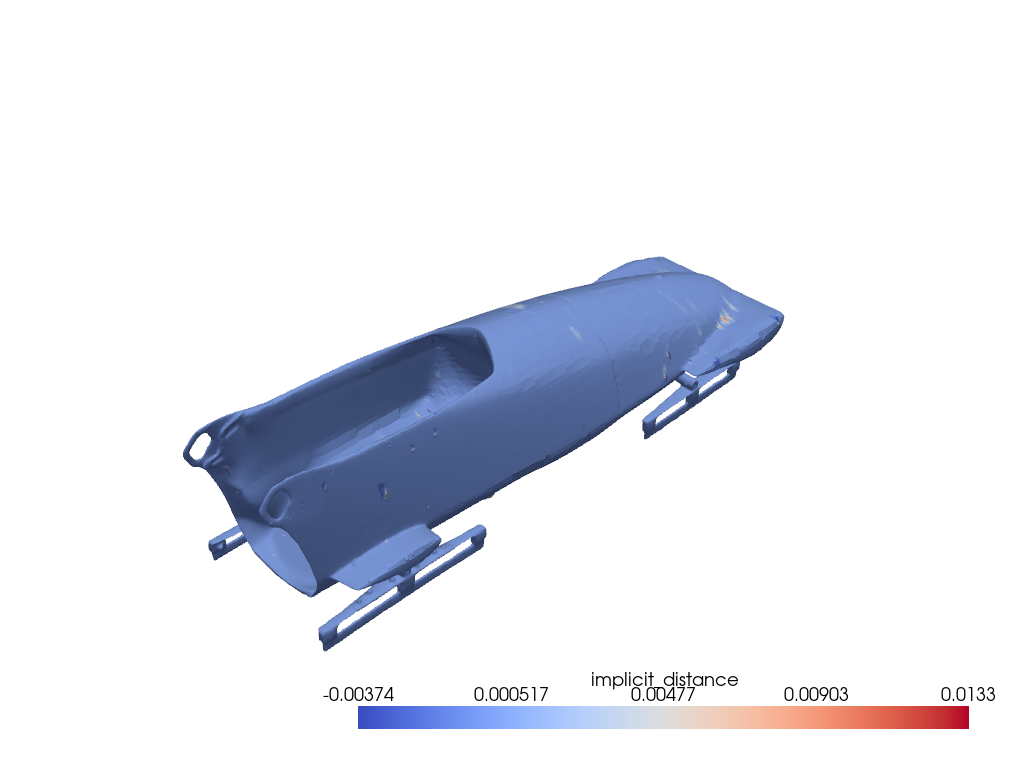

In [22]:
result.save("distance_map.vtk")

p = pv.Plotter()
p.add_mesh(result, scalars="implicit_distance", cmap="coolwarm")
p.show()

/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


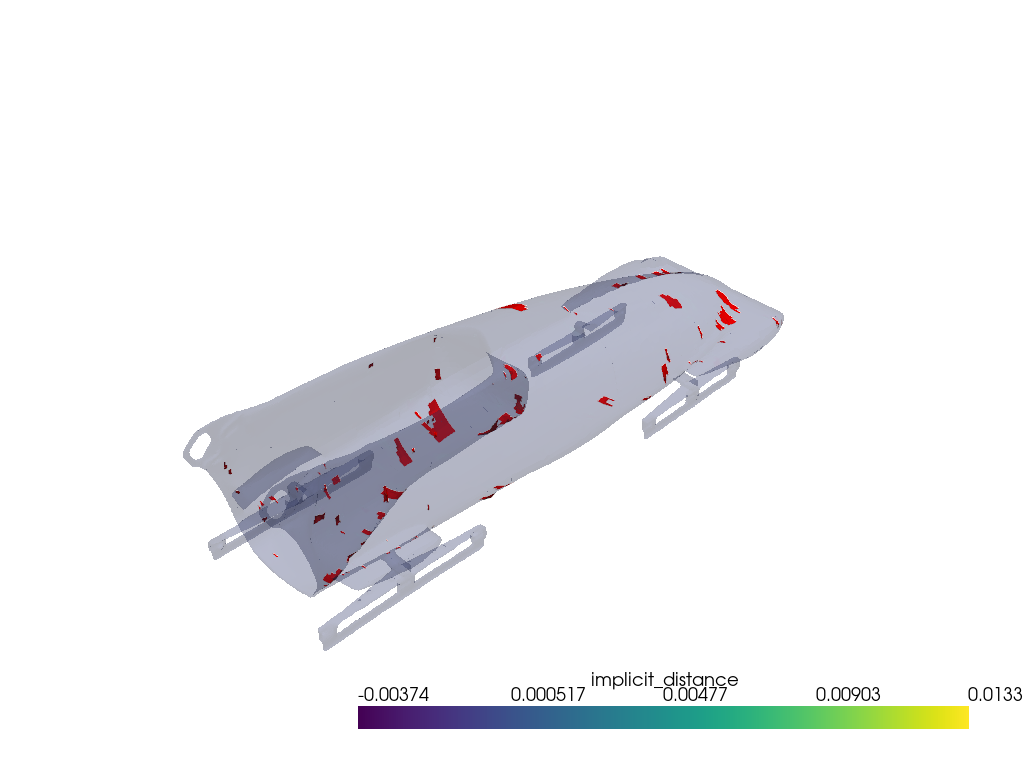

In [23]:
threshold = 0.002
bad = result.threshold(value=threshold, scalars="implicit_distance")
p = pv.Plotter()

p.add_mesh(result, scalars="implicit_distance", opacity=0.2)
p.add_mesh(bad, color="red")
p.show()

In [24]:
pts = bad.points

xmin, ymin, zmin = pts.min(axis=0)
xmax, ymax, zmax = pts.max(axis=0)

print(xmin, ymin, zmin)
print(xmax, ymax, zmax)

print(bad.n_points)

-1.3689189 -0.336572 0.081603706
1.2244298 0.40064186 0.6916041
1763


In [25]:
# localize the 26 mm deviation

imax = np.argmax(d)
pmax = mesh.points[imax]

print(d[imax])
print(pmax)

0.013290946114710255
[-0.99630535 -0.27758822  0.29514596]


/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


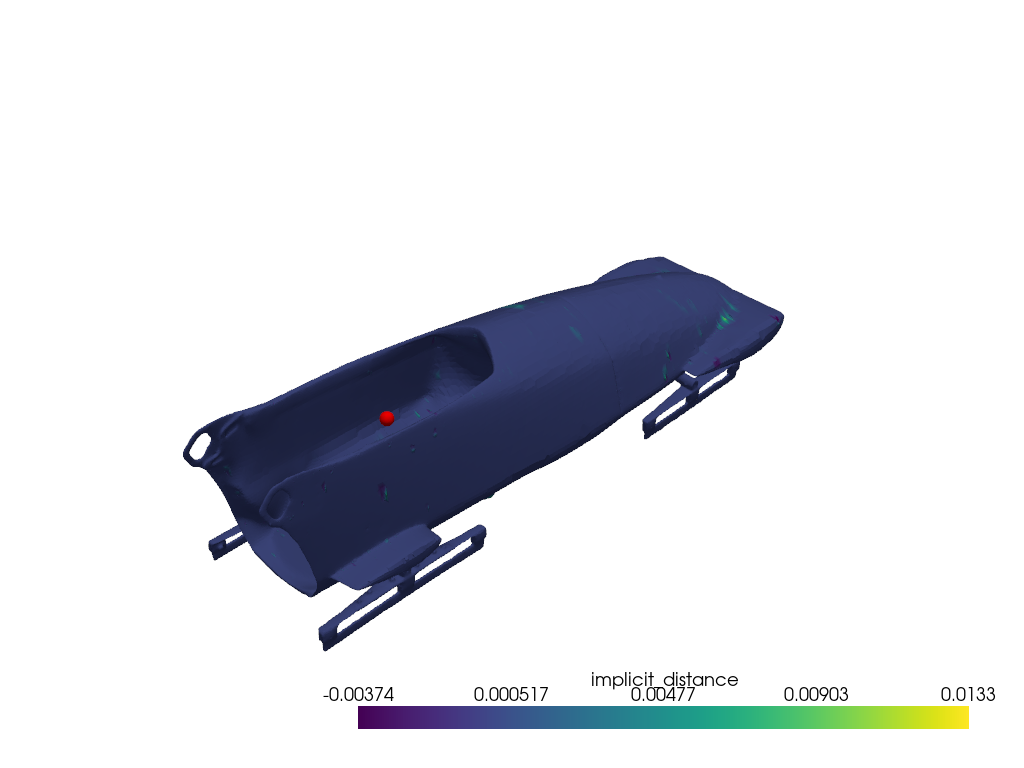

In [26]:
# visualize troublemaker spot
import pyvista as pv

sphere = pv.Sphere(radius=0.03, center=[0.48291054, -0.19614866, 0.35072783])

p = pv.Plotter()

p.add_mesh(result, scalars="implicit_distance")
p.add_mesh(sphere, color="red")

p.show()

In [4]:
import pyvista as pv
import numpy as np

SKEW_LIMIT = 4.0
surf = pv.read("VTK/01_mono_0/boundary/monobob.vtp")
wall_skew = surf["skewness"]
total_area = surf.area

bad = surf.threshold(value=SKEW_LIMIT, scalars="skewness")
bad_area = bad.area

ratio = 100.0 * bad_area / total_area

print("\n===================================")
print(" MONOBOB WALL SKEWNESS ANALYSIS")
print("===================================")

print(f"Total surface area : {total_area:.6f} m²")
print(f"Bad surface area   : {bad_area:.6f} m²")
print(f"Area ratio         : {ratio:.4f} %")

print(f"\nThreshold skewness : {SKEW_LIMIT}")

print(f"\nMax wall skewness  : {wall_skew.max():.4f}")
print(f"Mean wall skewness : {wall_skew.mean():.4f}")
print(f"Median skewness    : {np.median(wall_skew):.4f}")

surf.save("monobob_surface_with_skewness.vtp")
bad.save("bad_skew_regions.vtu")


 MONOBOB WALL SKEWNESS ANALYSIS
Total surface area : 7.461142 m²
Bad surface area   : 0.000003 m²
Area ratio         : 0.0000 %

Threshold skewness : 4.0

Max wall skewness  : 6.8100
Mean wall skewness : 0.2501
Median skewness    : 0.1649


ValueError: Invalid file extension for this data type. Must be one of: ['.vtu', '.vtk', '.vtkhdf', '.pkl', '.pickle']

In [ ]:
surf.plot(scalars="skewness", cmap="turbo", show_edges=False)
bad.plot(color="red")